# Step 4 & 5: Model Development & Evaluation
**Project:** Taobao CTR Prediction — Big Data Pipeline  
**Models:** Logistic Regression | Random Forest | Gradient Boosted Trees  
**Target:** `clk` (1 = clicked, 0 = not clicked)

## Cell 0 — HADOOP Setup

In [1]:
import os

os.environ["HADOOP_HOME"]     = r"C:\Users\Ahmed\Desktop\Project Big-Data\hadoop"
os.environ["hadoop.home.dir"] = r"C:\Users\Ahmed\Desktop\Project Big-Data\hadoop"
os.environ["PATH"]            = r"C:\Users\Ahmed\Desktop\Project Big-Data\hadoop\bin;" + os.environ["PATH"]

print("✅ HADOOP_HOME:", os.environ["HADOOP_HOME"])
print("✅ Hadoop configured!")

✅ HADOOP_HOME: C:\Users\Ahmed\Desktop\Project Big-Data\hadoop
✅ Hadoop configured!


## Cell 1 — Spark Session & Imports

In [19]:
import findspark
findspark.init()

import os
import warnings
warnings.filterwarnings('ignore')

from pyspark.sql import SparkSession
from pyspark.sql.functions import col
from pyspark.ml.classification import (
    LogisticRegression,
    RandomForestClassifier,
    GBTClassifier
)
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    MulticlassClassificationEvaluator
)
from sklearn.metrics import classification_report
from pyspark.ml.classification import LogisticRegressionModel
from pyspark.ml.classification import RandomForestClassificationModel
from pyspark.ml.classification import GBTClassificationModel
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time

OUTPUT_PATH = r"C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData"
TRAIN_PATH  = r"C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\processed_dataprocessed_data\train"
TEST_PATH   = r"C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\processed_dataprocessed_data\test"
MODEL_PATH  = OUTPUT_PATH + "\models/"
CHARTS_PATH = r"C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\charts/"

os.makedirs(MODEL_PATH,  exist_ok=True)
os.makedirs(CHARTS_PATH, exist_ok=True)

spark = SparkSession.builder \
    .appName("Taobao_CTR_Modeling") \
    .config("spark.driver.memory", "8g") \
    .config("spark.executor.memory", "8g") \
    .config("spark.driver.maxResultSize", "4g") \
    .config("spark.sql.shuffle.partitions", "4") \
    .config("spark.network.timeout", "800s") \
    .config("spark.executor.heartbeatInterval", "60s") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")
print("✅ Spark Version:", spark.version)
print("✅ Spark Session Started!")

✅ Spark Version: 4.1.1
✅ Spark Session Started!


## Cell 2 — Load Processed Data

In [3]:
print(" Loading processed data...\n")

train_df = spark.read.parquet(TRAIN_PATH)
test_df  = spark.read.parquet(TEST_PATH)

print("Count of data Before samplint")
train_count = print("Train: ", train_df.count())
test_count  = print("Test: ", test_df.count())

train_df = train_df.sample(withReplacement=False, fraction=0.5, seed=42)
test_df = test_df.sample(withReplacement=False, fraction=0.5, seed=42)

print("Count of data after samplint")
train_count = print("Train: ", train_df.count())
test_count  = print("Test: ", test_df.count())

train_df.cache()
test_df.cache()

print("\n Data loaded & cached!")

 Loading processed data...

Count of data Before samplint
Train:  23249296
Test:  3308665
Count of data after samplint
Train:  11622765
Test:  1655625

 Data loaded & cached!


## Cell 3 — Helper: Evaluation Function

In [4]:
def evaluate_model(train_predictions, test_predictions, model_name):
    binary_eval = BinaryClassificationEvaluator(
        labelCol="clk",
        rawPredictionCol="rawPrediction",
        metricName="areaUnderROC"
    )
    multi_eval = MulticlassClassificationEvaluator(
        labelCol="clk",
        predictionCol="prediction"
    )

    train_auc      = binary_eval.evaluate(train_predictions)
    train_accuracy = multi_eval.setMetricName("accuracy").evaluate(train_predictions)

    test_auc       = binary_eval.evaluate(test_predictions)
    test_accuracy  = multi_eval.setMetricName("accuracy").evaluate(test_predictions)
    test_precision = multi_eval.setMetricName("weightedPrecision").evaluate(test_predictions)
    test_recall    = multi_eval.setMetricName("weightedRecall").evaluate(test_predictions)
    test_f1        = multi_eval.setMetricName("f1").evaluate(test_predictions)

    results = {
        "Model"          : model_name,
        "Train AUC-ROC"  : round(train_auc,      4),
        "Test AUC-ROC"   : round(test_auc,       4),
        "Train Accuracy" : round(train_accuracy, 4),
        "Test Accuracy"  : round(test_accuracy,  4),
        "Test Precision" : round(test_precision, 4),
        "Test Recall"    : round(test_recall,    4),
        "Test F1-Score"  : round(test_f1,        4)
    }

    print(f"\n {'='*40}")
    print(f"   {model_name} Results:")
    print(f" {'='*40}")
    print(f"     Train AUC-ROC  : {train_auc:.4f}  |  Test AUC-ROC  : {test_auc:.4f}")
    print(f"     Train Accuracy : {train_accuracy:.4f}  |  Test Accuracy : {test_accuracy:.4f}")
    print(f" {'-'*40}")
    print(f"     Test Precision : {test_precision:.4f}")
    print(f"     Test Recall    : {test_recall:.4f}")
    print(f"     Test F1-Score  : {test_f1:.4f}")
    print(f" {'-'*40}")

    return results

all_results = []
print(" Evaluation function ready!")

 Evaluation function ready!


## Cell 4 — Model 1: Logistic Regression

In [5]:
print(" MODEL 1: LOGISTIC REGRESSION")
print("=" * 50)

start = time.time()

lr = LogisticRegression(
    featuresCol="features",
    labelCol="clk",
    weightCol="class_weight",
    maxIter=100,
    regParam=0.01,
    elasticNetParam=0.5,
    standardization=False
)

print("Training Logistic Regression...")
lr_model       = lr.fit(train_df)
lr_train_predictions = lr_model.transform(train_df)
lr_test_predictions  = lr_model.transform(test_df)

elapsed = round(time.time() - start, 2)
print(f"   Training done in {elapsed}s")

lr_results = evaluate_model(lr_train_predictions, lr_test_predictions, "Logistic Regression")
all_results.append(lr_results)

lr_model.write().overwrite().save(MODEL_PATH + "logistic_regression")
print(f"\n   Model saved → {MODEL_PATH}logistic_regression")
print("\n Logistic Regression complete!")
print(lr_train_predictions, lr_test_predictions)

 MODEL 1: LOGISTIC REGRESSION
Training Logistic Regression...
   Training done in 30.74s

   Logistic Regression Results:
     Train AUC-ROC  : 0.8226  |  Test AUC-ROC  : 0.8263
     Train Accuracy : 0.7830  |  Test Accuracy : 0.7749
 ----------------------------------------
     Test Precision : 0.9373
     Test Recall    : 0.7749
     Test F1-Score  : 0.8361
 ----------------------------------------

   Model saved → C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\models/logistic_regression

 Logistic Regression complete!
DataFrame[features: vector, clk: int, class_weight: double, rawPrediction: vector, probability: vector, prediction: double] DataFrame[features: vector, clk: int, class_weight: double, rawPrediction: vector, probability: vector, prediction: double]


In [6]:
y_true = lr_test_predictions.select("clk").toPandas()
y_pred = lr_test_predictions.select("prediction").toPandas()

print("\n" + "="*20 + " CLASSIFICATION REPORT " + "="*20)
print(classification_report(y_true, y_pred, target_names=["Not Clicked", "Clicked"]))
print("="*63)


==================== CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

 Not Clicked       0.98      0.78      0.87   1571870
     Clicked       0.14      0.69      0.24     83755

    accuracy                           0.77   1655625
   macro avg       0.56      0.74      0.55   1655625
weighted avg       0.94      0.77      0.84   1655625



## Cell 5 — Model 2: Random Forest

In [7]:
print("MODEL 2: RANDOM FOREST")
print("=" * 50)

import time
from pyspark.ml.classification import RandomForestClassifier

start = time.time()

rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="clk",
    weightCol="class_weight",
    numTrees=100,
    maxDepth=8,
    featureSubsetStrategy="sqrt",
    seed=42
)

print("Training Random Forest...")
rf_model = rf.fit(train_df)

rf_train_predictions = rf_model.transform(train_df)
rf_test_predictions  = rf_model.transform(test_df)

elapsed = round(time.time() - start, 2)
print(f"   Training done in {elapsed}s")

rf_results = evaluate_model(rf_train_predictions, rf_test_predictions, "Random Forest")
all_results.append(rf_results)

print("\n   Top 10 Feature Importances:")
importances = rf_model.featureImportances.toArray()
top10_idx   = importances.argsort()[-10:][::-1]
for i, idx in enumerate(top10_idx):
    print(f"     {i+1}. Feature[{idx}]: {importances[idx]:.4f}")

rf_model.write().overwrite().save(MODEL_PATH + "random_forest")
print(f"\n   Model saved → {MODEL_PATH}random_forest")
print("\n Random Forest complete!")

MODEL 2: RANDOM FOREST
Training Random Forest...
   Training done in 405.13s

   Random Forest Results:
     Train AUC-ROC  : 0.8309  |  Test AUC-ROC  : 0.8342
     Train Accuracy : 0.6754  |  Test Accuracy : 0.6710
 ----------------------------------------
     Test Precision : 0.9428
     Test Recall    : 0.6710
     Test F1-Score  : 0.7629
 ----------------------------------------

   Top 10 Feature Importances:
     1. Feature[4]: 0.5821
     2. Feature[1]: 0.2383
     3. Feature[3]: 0.1578
     4. Feature[2]: 0.0150
     5. Feature[0]: 0.0020
     6. Feature[5]: 0.0017
     7. Feature[20]: 0.0016
     8. Feature[6]: 0.0004
     9. Feature[9]: 0.0003
     10. Feature[10]: 0.0002

   Model saved → C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\models/random_forest

 Random Forest complete!


In [8]:
y_true = rf_test_predictions.select("clk").toPandas()
y_pred = rf_test_predictions.select("prediction").toPandas()

print("\n" + "="*20 + " TEST CLASSIFICATION REPORT " + "="*20)
print(classification_report(y_true, y_pred, target_names=["Not Clicked", "Clicked"]))
print("="*63)


==================== TEST CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

 Not Clicked       0.99      0.66      0.79   1571870
     Clicked       0.12      0.83      0.20     83755

    accuracy                           0.67   1655625
   macro avg       0.55      0.75      0.50   1655625
weighted avg       0.94      0.67      0.76   1655625



## Cell 6 — Model 3: Gradient Boosted Trees

In [9]:
print("MODEL 3: GRADIENT BOOSTED TREES")
print("=" * 50)

start = time.time()

gbt = GBTClassifier(
    featuresCol="features",
    labelCol="clk",
    weightCol="class_weight",
    maxDepth=4,     
    maxIter=30,               
    stepSize=0.1,      
    subsamplingRate=0.8,  
    minInstancesPerNode=10,
    seed=42
)

print(" Training GBT...")
gbt_model       = gbt.fit(train_df)

gbt_train_predictions = gbt_model.transform(train_df)
gbt_test_predictions  = gbt_model.transform(test_df)

elapsed = round(time.time() - start, 2)
print(f"   Training done in {elapsed}s")

gbt_results = evaluate_model(gbt_train_predictions, gbt_test_predictions, "GBT")
all_results.append(gbt_results)

print("\n   Top 10 Feature Importances:")
importances = gbt_model.featureImportances.toArray()
top10_idx   = importances.argsort()[-10:][::-1]
for i, idx in enumerate(top10_idx):
    print(f"     {i+1}. Feature[{idx}]: {importances[idx]:.4f}")

gbt_model.write().overwrite().save(MODEL_PATH + "gbt")
print(f"\n   Model saved → {MODEL_PATH}gbt")
print("\n GBT complete!")

MODEL 3: GRADIENT BOOSTED TREES
 Training GBT...
   Training done in 120.41s

   GBT Results:
     Train AUC-ROC  : 0.8359  |  Test AUC-ROC  : 0.8397
     Train Accuracy : 0.7295  |  Test Accuracy : 0.7219
 ----------------------------------------
     Test Precision : 0.9411
     Test Recall    : 0.7219
     Test F1-Score  : 0.7999
 ----------------------------------------

   Top 10 Feature Importances:
     1. Feature[4]: 0.6415
     2. Feature[1]: 0.3308
     3. Feature[2]: 0.0211
     4. Feature[3]: 0.0060
     5. Feature[9]: 0.0005
     6. Feature[7]: 0.0000
     7. Feature[5]: 0.0000
     8. Feature[0]: 0.0000
     9. Feature[15]: 0.0000
     10. Feature[13]: 0.0000

   Model saved → C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData\models/gbt

 GBT complete!


In [10]:
y_true = gbt_test_predictions.select("clk").toPandas()
y_pred = gbt_test_predictions.select("prediction").toPandas()

print("\n" + "="*20 + " TEST CLASSIFICATION REPORT " + "="*20)
print(classification_report(y_true, y_pred, target_names=["Not Clicked", "Clicked"]))
print("="*63)


==================== TEST CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

 Not Clicked       0.98      0.72      0.83   1571870
     Clicked       0.13      0.79      0.22     83755

    accuracy                           0.72   1655625
   macro avg       0.56      0.75      0.53   1655625
weighted avg       0.94      0.72      0.80   1655625



## Cell 7 — Models Comparison Table

 MODELS COMPARISON

                      Train AUC-ROC  Test AUC-ROC  Train Accuracy  Test Accuracy  Test Precision  Test Recall  Test F1-Score
Model                                                                                                                      
Logistic Regression         0.8226        0.8263          0.7830         0.7749          0.9373       0.7749         0.8361
Random Forest               0.8309        0.8342          0.6754         0.6710          0.9428       0.6710         0.7629
GBT                         0.8359        0.8397          0.7295         0.7219          0.9411       0.7219         0.7999

   Best Model : GBT
     Test AUC-ROC : 0.8397


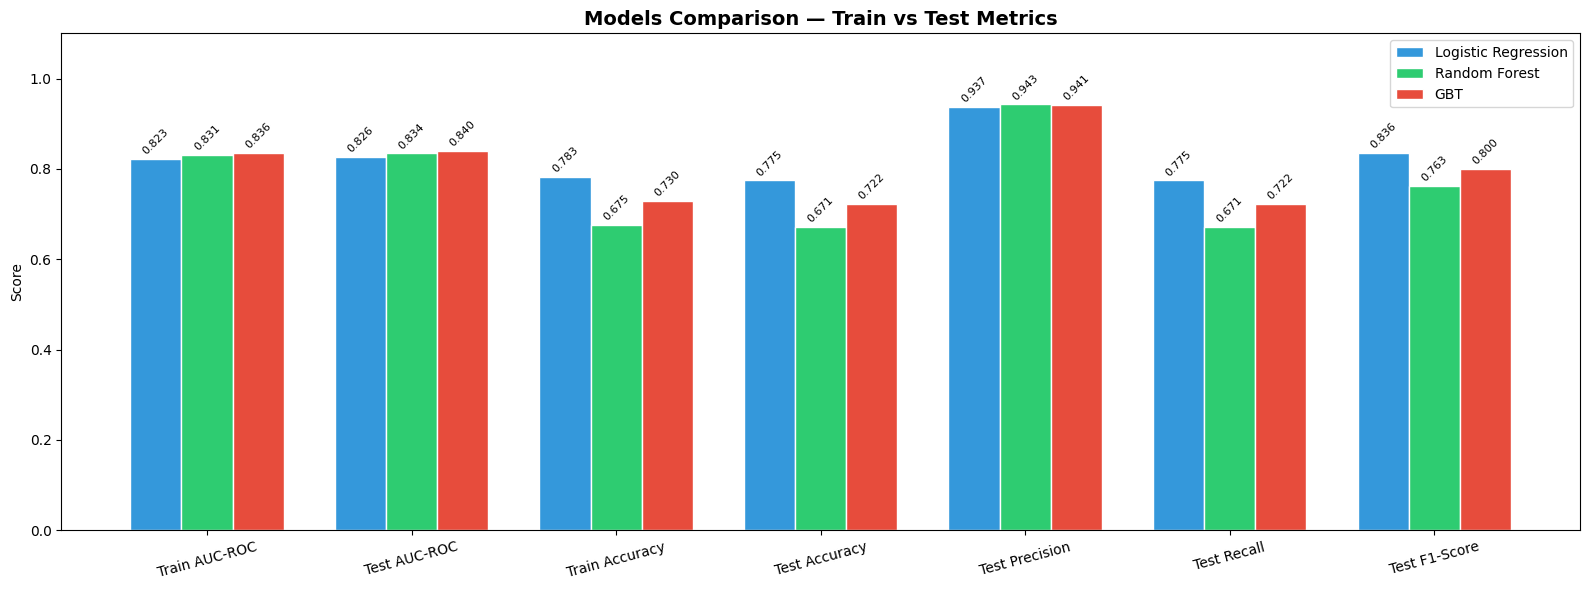

 Comparison chart saved!


In [22]:
print("=" * 60)
print(" MODELS COMPARISON")
print("=" * 60)

results_df = pd.DataFrame(all_results)
results_df = results_df.set_index("Model")

print("\n", results_df.to_string())

best_model = results_df["Test AUC-ROC"].idxmax()
best_auc   = results_df["Test AUC-ROC"].max()

print(f"\n   Best Model : {best_model}")
print(f"     Test AUC-ROC : {best_auc:.4f}")

metrics   = [
    "Train AUC-ROC", "Test AUC-ROC", 
    "Train Accuracy", "Test Accuracy", 
    "Test Precision", "Test Recall", "Test F1-Score"
]

x         = range(len(metrics))
colors    = ["#3498db", "#2ecc71", "#e74c3c"]
bar_width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

for i, (model_name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(
        [xi + i * bar_width for xi in x],
        vals,
        width=bar_width,
        label=model_name,
        color=colors[i],
        edgecolor="white"
    )

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8, rotation=45
        )

ax.set_xticks([xi + bar_width for xi in x])
ax.set_xticklabels(metrics, rotation=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Models Comparison — Train vs Test Metrics", fontsize=14, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(CHARTS_PATH + "models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Comparison chart saved!")

## Cell 8 — Feature Importance Chart

 FEATURE IMPORTANCE — RF vs GBT


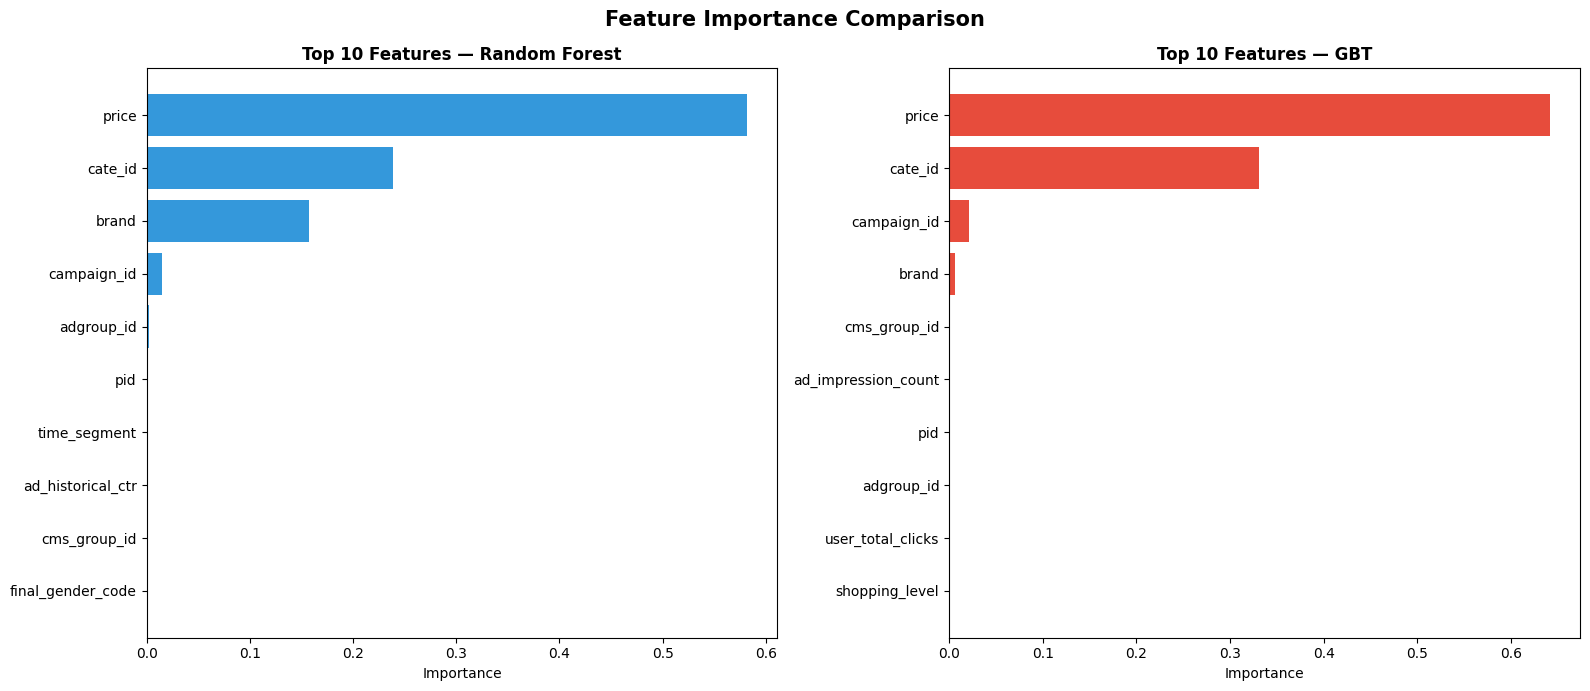

 Feature importance chart saved!


In [23]:
print(" FEATURE IMPORTANCE — RF vs GBT")
print("=" * 50)

feature_names = [
    "adgroup_id", "cate_id", "campaign_id", "brand", "price",
    "pid", "ad_historical_ctr", "ad_impression_count",
    "cms_segid", "cms_group_id", "final_gender_code",
    "age_level", "pvalue_level", "shopping_level",
    "occupation", "user_total_clicks", "user_ctr",
    "hour", "day_of_week", "is_weekend", "time_segment"
]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, model, name, color in zip(
    axes,
    [rf_model, gbt_model],
    ["Random Forest", "GBT"],
    ["#3498db", "#e74c3c"]
):
    importances = model.featureImportances.toArray()
    n           = min(len(importances), len(feature_names))
    imp_df      = pd.DataFrame({
        "Feature"   : feature_names[:n],
        "Importance": importances[:n]
    }).sort_values("Importance", ascending=False).head(10)

    ax.barh(imp_df["Feature"], imp_df["Importance"], color=color)
    ax.set_title(f"Top 10 Features — {name}", fontweight="bold")
    ax.set_xlabel("Importance")
    ax.invert_yaxis()

plt.suptitle("Feature Importance Comparison", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig(CHARTS_PATH + "feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Feature importance chart saved!")

## Cell 9 — Confusion Matrix

CONFUSION MATRICES


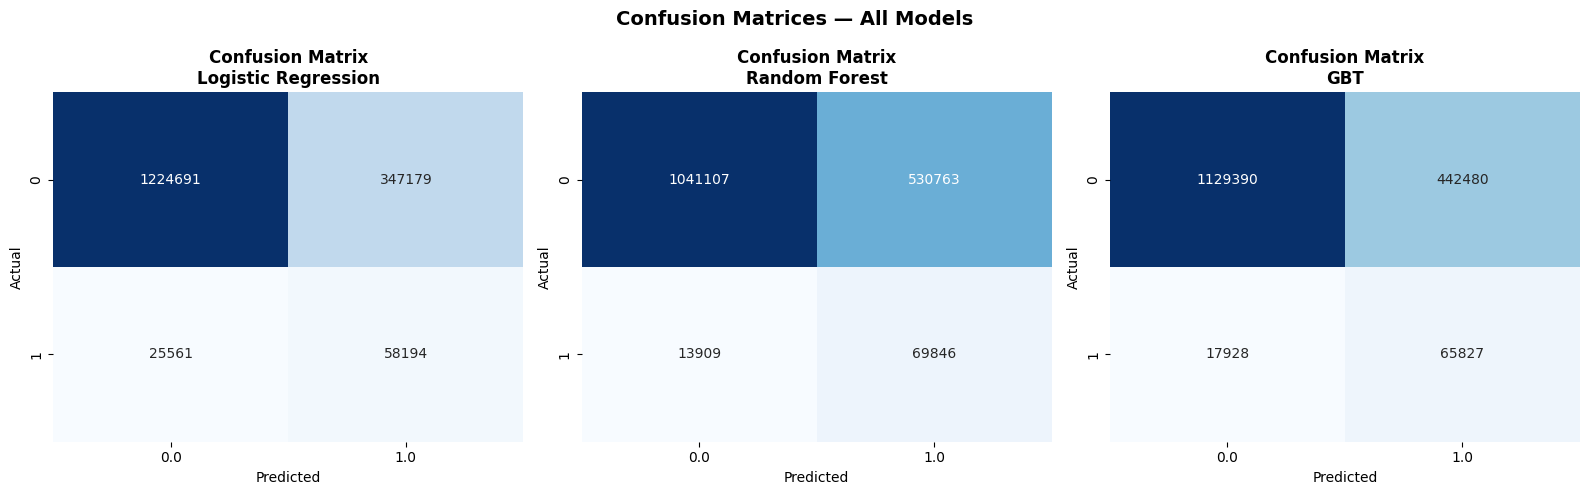

Confusion matrices saved!


In [24]:
print("CONFUSION MATRICES")
print("=" * 50)

def plot_confusion_matrix(predictions, model_name, ax):
    cm = predictions.groupBy("clk", "prediction") \
        .count().toPandas()

    matrix = pd.pivot_table(
        cm,
        values="count",
        index="clk",
        columns="prediction",
        fill_value=0
    )

    matrix = matrix.astype(int)

    sns.heatmap(
        matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=ax,
        cbar=False
    )
    ax.set_title(f"Confusion Matrix\n{model_name}", fontweight="bold")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

plot_confusion_matrix(lr_test_predictions,  "Logistic Regression", axes[0])
plot_confusion_matrix(rf_test_predictions,  "Random Forest",       axes[1])
plot_confusion_matrix(gbt_test_predictions, "GBT",                 axes[2])

plt.suptitle("Confusion Matrices — All Models", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(CHARTS_PATH + "confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Confusion matrices saved!")

## Cell 10 — Final Summary & Interpretation

 MODELS COMPARISON

                      Train AUC-ROC  Test AUC-ROC  Train Accuracy  Test Accuracy  Test Precision  Test Recall  Test F1-Score
Model                                                                                                                      
Logistic Regression         0.8226        0.8263          0.7830         0.7749          0.9373       0.7749         0.8361
Random Forest               0.8309        0.8342          0.6754         0.6710          0.9428       0.6710         0.7629
GBT                         0.8359        0.8397          0.7295         0.7219          0.9411       0.7219         0.7999

   Best Model : GBT
     Test AUC-ROC : 0.8397


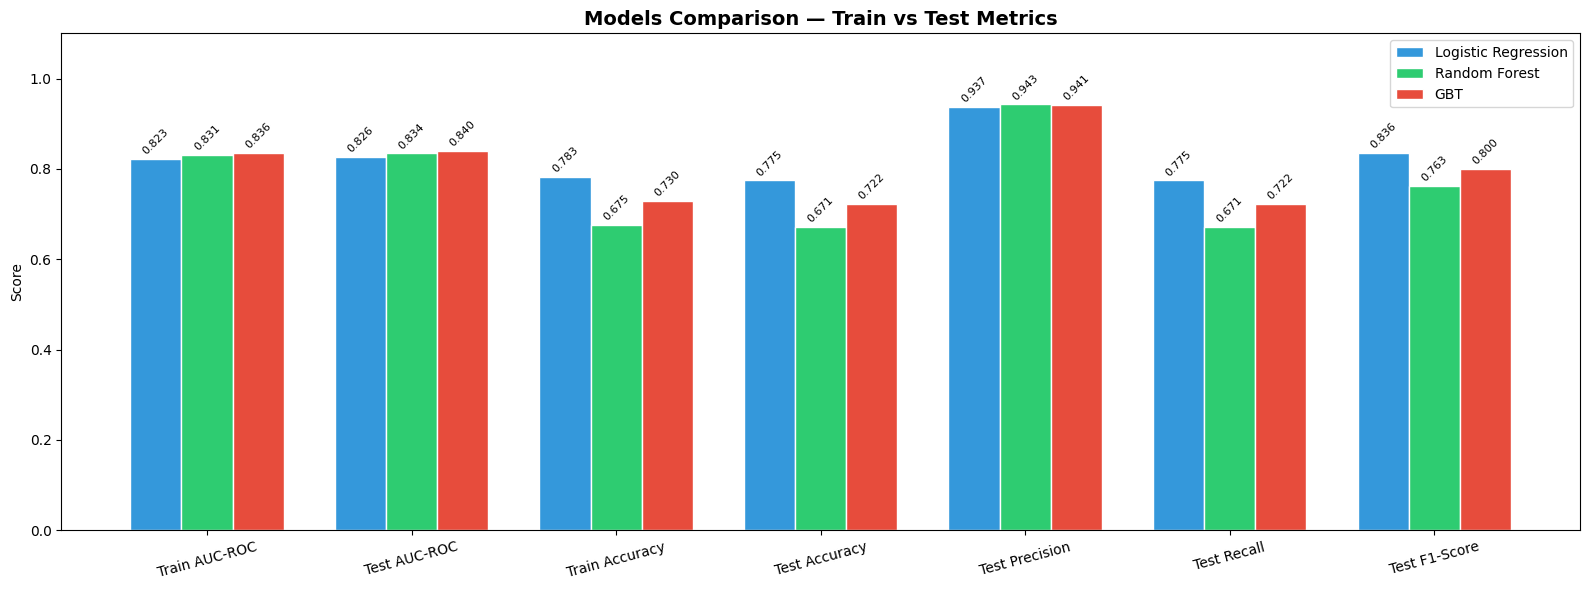

 Comparison chart saved!


In [25]:
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 60)
print(" MODELS COMPARISON")
print("=" * 60)

results_df = pd.DataFrame(all_results)
results_df = results_df.set_index("Model")

print("\n", results_df.to_string())

best_model = results_df["Test AUC-ROC"].idxmax()
best_auc   = results_df["Test AUC-ROC"].max()

print(f"\n   Best Model : {best_model}")
print(f"     Test AUC-ROC : {best_auc:.4f}")

metrics   = [
    "Train AUC-ROC", "Test AUC-ROC", 
    "Train Accuracy", "Test Accuracy", 
    "Test Precision", "Test Recall", "Test F1-Score"
]

x         = range(len(metrics))
colors    = ["#3498db", "#2ecc71", "#e74c3c"]
bar_width = 0.25

fig, ax = plt.subplots(figsize=(16, 6))

for i, (model_name, row) in enumerate(results_df.iterrows()):
    vals = [row[m] for m in metrics]
    bars = ax.bar(
        [xi + i * bar_width for xi in x],
        vals,
        width=bar_width,
        label=model_name,
        color=colors[i],
        edgecolor="white"
    )

    for bar, val in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.005,
            f"{val:.3f}",
            ha="center", va="bottom", fontsize=8, rotation=45
        )

ax.set_xticks([xi + bar_width for xi in x])
ax.set_xticklabels(metrics, rotation=15)
ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Models Comparison — Train vs Test Metrics", fontsize=14, fontweight="bold")
ax.legend()

plt.tight_layout()
plt.savefig(CHARTS_PATH + "models_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(" Comparison chart saved!")

In [26]:
saved_model_path = MODEL_PATH + "logistic_regression"
loaded_lr_model = LogisticRegressionModel.load(saved_model_path)

lr_train_predictions = loaded_lr_model.transform(train_df)
lr_test_predictions  = loaded_lr_model.transform(test_df)

evaluate_model(lr_train_predictions, lr_test_predictions, "logistic regression")


   logistic regression Results:
     Train AUC-ROC  : 0.8226  |  Test AUC-ROC  : 0.8263
     Train Accuracy : 0.7830  |  Test Accuracy : 0.7749
 ----------------------------------------
     Test Precision : 0.9373
     Test Recall    : 0.7749
     Test F1-Score  : 0.8361
 ----------------------------------------


{'Model': 'logistic regression',
 'Train AUC-ROC': 0.8226,
 'Test AUC-ROC': 0.8263,
 'Train Accuracy': 0.783,
 'Test Accuracy': 0.7749,
 'Test Precision': 0.9373,
 'Test Recall': 0.7749,
 'Test F1-Score': 0.8361}

In [27]:
saved_rf_path = MODEL_PATH + "random_forest"
loaded_rf_model = RandomForestClassificationModel.load(saved_rf_path)

rf_train_predictions = loaded_rf_model.transform(train_df)
rf_test_predictions  = loaded_rf_model.transform(test_df)

evaluate_model(rf_train_predictions, rf_test_predictions, "random forest")


   random forest Results:
     Train AUC-ROC  : 0.8309  |  Test AUC-ROC  : 0.8342
     Train Accuracy : 0.6754  |  Test Accuracy : 0.6710
 ----------------------------------------
     Test Precision : 0.9428
     Test Recall    : 0.6710
     Test F1-Score  : 0.7629
 ----------------------------------------


{'Model': 'random forest',
 'Train AUC-ROC': 0.8309,
 'Test AUC-ROC': 0.8342,
 'Train Accuracy': 0.6754,
 'Test Accuracy': 0.671,
 'Test Precision': 0.9428,
 'Test Recall': 0.671,
 'Test F1-Score': 0.7629}

In [28]:
saved_gpt_path = MODEL_PATH + "gbt"
loaded_gbt_model = GBTClassificationModel.load(saved_gpt_path)

gbt_train_predictions = loaded_gbt_model.transform(train_df)
gbt_test_predictions  = loaded_gbt_model.transform(test_df)

evaluate_model(gbt_train_predictions, gbt_test_predictions, "gbt")


   gbt Results:
     Train AUC-ROC  : 0.8359  |  Test AUC-ROC  : 0.8397
     Train Accuracy : 0.7295  |  Test Accuracy : 0.7219
 ----------------------------------------
     Test Precision : 0.9411
     Test Recall    : 0.7219
     Test F1-Score  : 0.7999
 ----------------------------------------


{'Model': 'gbt',
 'Train AUC-ROC': 0.8359,
 'Test AUC-ROC': 0.8397,
 'Train Accuracy': 0.7295,
 'Test Accuracy': 0.7219,
 'Test Precision': 0.9411,
 'Test Recall': 0.7219,
 'Test F1-Score': 0.7999}

In [29]:
results_df

,Train AUC-ROC,Test AUC-ROC,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1-Score
Model,,,,,,,
Logistic Regression,0.8226,0.8263,0.7830,0.7749,0.9373,0.7749,0.8361
Random Forest,0.8309,0.8342,0.6754,0.6710,0.9428,0.6710,0.7629
GBT,0.8359,0.8397,0.7295,0.7219,0.9411,0.7219,0.7999


In [ ]:
RESULTS_PATH = r"C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigData"
results_df.to_csv(RESULTS_PATH + "models_evaluation_r00esults.csv")

print(f"✅ Results saved successfully to {RESULTS_PATH}models_evaluation_results.csv")

✅ Results saved successfully to C:\Users\Ahmed\Desktop\Project Big-Data\ProjectBigDatamodels_evaluation_results.csv


In [ ]:
results_df

,Train AUC-ROC,Test AUC-ROC,Train Accuracy,Test Accuracy,Test Precision,Test Recall,Test F1-Score
Model,,,,,,,
Logistic Regression,0.8226,0.8263,0.7830,0.7749,0.9373,0.7749,0.8361
Random Forest,0.8309,0.8342,0.6754,0.6710,0.9428,0.6710,0.7629
GBT,0.8359,0.8397,0.7295,0.7219,0.9411,0.7219,0.7999
